# **Tahap 5**

**Persiapan Library & Data**

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

print("=== PERSIAPAN DATA EVALUASI ===")

queries = df_test['Dakwaan'].tolist()
ground_truth = df_test['Pasal'].tolist()

all_labels = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in df_train['Pasal'].tolist() + ground_truth]
mlb = MultiLabelBinarizer()
mlb.fit(all_labels)

print("Data query, ground truth, dan Binarizer siap")

=== PERSIAPAN DATA EVALUASI ===
Data query, ground truth, dan Binarizer siap


**Evaluasi Retrieval**

**Evaluasi Prediksi**

In [29]:
from sklearn.metrics import jaccard_score

print("=== EVALUASI PREDIKSI FINAL ===")

y_pred_final = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in df_predictions['predicted_solution'].tolist()]
y_true_final = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in ground_truth]

y_true_bin_final = mlb.transform(y_true_final)
y_pred_bin_final = mlb.transform(y_pred_final)

df_pred_metrics = pd.DataFrame([{
    "Model": "Final Prediction (Majority Vote)",
    "Accuracy": jaccard_score(y_true_bin_final, y_pred_bin_final, average='samples'),
    "Precision": precision_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0),
    "Recall": recall_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0),
    "F1-Score": f1_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0)
}])

df_pred_metrics = df_pred_metrics.round({"Accuracy": 4, "Precision": 4, "Recall": 4, "F1-Score": 4})
display(df_pred_metrics)
print(" Evaluasi Prediksi Selesai ")

=== EVALUASI PREDIKSI FINAL ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Final Prediction (Majority Vote),0.2145,0.4444,0.2326,0.3053


 Evaluasi Prediksi Selesai 


**Visualisasi dan Output ke CSV**

**Tabel Metrik Perbandingan**

In [24]:
import pandas as pd

print("=== TABEL METRIK PER MODEL ===\n")

df_all_models = pd.concat([df_retrieval_metrics, df_pred_metrics], ignore_index=True)

try:
    display(df_all_models)
except NameError:
    pass

print(df_all_models.to_string(index=False))

print("\nTabel perbandingan berhasil dibuat! Silakan lanjut running sel grafik di bawah.")

=== TABEL METRIK PER MODEL ===



,Model,Accuracy,Precision,Recall,F1-Score
0,Retrieval (Top-5),0.773276,0.37338,0.712492,0.47526
1,Final Prediction (Majority Vote),0.214500,0.44440,0.232600,0.30530


                           Model  Accuracy  Precision   Recall  F1-Score
               Retrieval (Top-5)  0.773276    0.37338 0.712492   0.47526
Final Prediction (Majority Vote)  0.214500    0.44440 0.232600   0.30530

Tabel perbandingan berhasil dibuat! Silakan lanjut running sel grafik di bawah.


**Plot Bar Chart Performance (Side-by-Side)**

=== PLOT BAR CHART PERFORMANCE ===


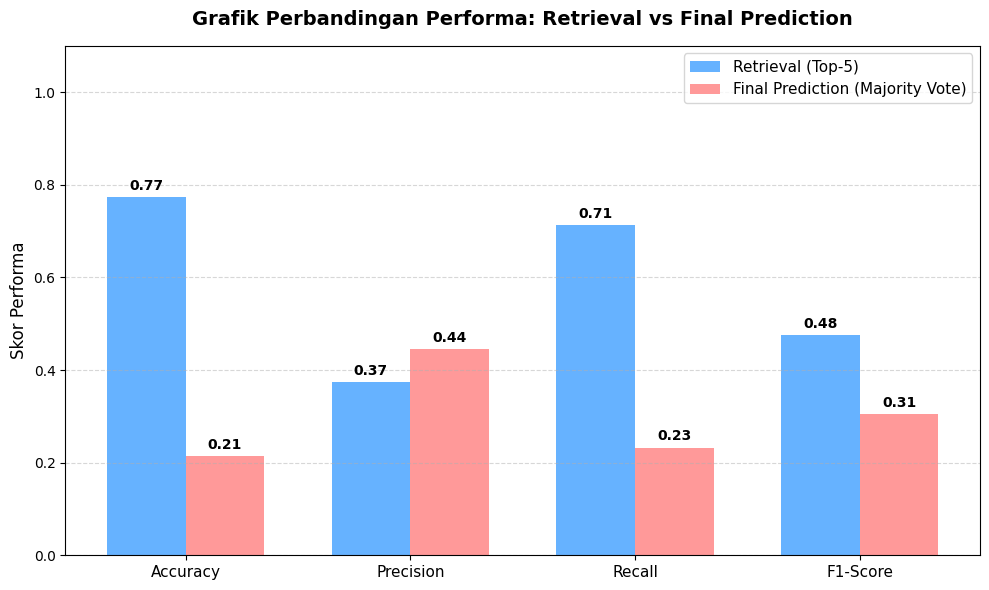

In [25]:
print("=== PLOT BAR CHART PERFORMANCE ===")

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
retrieval_scores = df_retrieval_metrics.iloc[0, 1:5].values.astype(float)
prediction_scores = df_pred_metrics.iloc[0, 1:5].values.astype(float)

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, retrieval_scores, width, label='Retrieval (Top-5)', color='#66B2FF')
rects2 = ax.bar(x + width/2, prediction_scores, width, label='Final Prediction (Majority Vote)', color='#FF9999')

ax.set_ylabel('Skor Performa', fontsize=12)
ax.set_title('Grafik Perbandingan Performa: Retrieval vs Final Prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def label_tiang(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

label_tiang(rects1)
label_tiang(rects2)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score # <-- Pastikan jaccard_score sudah di-import

print("=== EVALUASI PREDIKSI FINAL ===")

y_pred_final = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in df_predictions['predicted_solution'].tolist()]
y_true_final = [[p.strip().lower() for p in str(pasal).split(',')] for pasal in ground_truth]

y_true_bin_final = mlb.transform(y_true_final)
y_pred_bin_final = mlb.transform(y_pred_final)

df_pred_metrics = pd.DataFrame([{
    "Model": "Final Prediction (Majority Vote)",
    # PERBAIKAN DI SINI: Mengubah accuracy_score menjadi jaccard_score berbasis samples
    "Accuracy": jaccard_score(y_true_bin_final, y_pred_bin_final, average='samples'),
    "Precision": precision_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0),
    "Recall": recall_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0),
    "F1-Score": f1_score(y_true_bin_final, y_pred_bin_final, average='micro', zero_division=0)
}])

# Tambahan biar tampilan angka desimalnya rapi (4 angka di belakang koma)
df_pred_metrics = df_pred_metrics.round(4)

display(df_pred_metrics)
print(" Evaluasi Prediksi Selesai ")

=== EVALUASI PREDIKSI FINAL ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Final Prediction (Majority Vote),0.2145,0.4444,0.2326,0.3053


 Evaluasi Prediksi Selesai 


In [ ]:
import os

print("=== PROSES MENYIMPAN OUTPUT CSV ===")

output_dir = os.path.join("data", "eval")
os.makedirs(output_dir, exist_ok=True)

path_retrieval = os.path.join(output_dir, "retrieval_metrics.csv")
path_prediction = os.path.join(output_dir, "prediction_metrics.csv")

df_retrieval_metrics.to_csv(path_retrieval, index=False)
df_pred_metrics.to_csv(path_prediction, index=False)

print(f"Output 1 sukses dibuat: {path_retrieval}")
print(f"Output 2 sukses dibuat: {path_prediction}")


=== PROSES MENYIMPAN OUTPUT CSV ===
Output 1 sukses dibuat: data/eval/retrieval_metrics.csv
Output 2 sukses dibuat: data/eval/prediction_metrics.csv
